In [ ]:
# !pip uninstall -y gensim
# !pip install gensim==4.3.2 numpy==1.25.2 scipy==1.10.1 --upgrade --force-reinstall

# PADL coursework

In [6]:
from google.colab import drive
drive.mount('/content/drive/')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, accuracy_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

# from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, f_regression

import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torchvision import models
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

from skimage.metrics import structural_similarity as ssim

PROJECT_DIRECTORY = '/content/drive/MyDrive/padl_ws/'
DATA_DIRECTORY = PROJECT_DIRECTORY + "data/"
MODEL_DIRECTORY = PROJECT_DIRECTORY + "models/"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q11-train.csv'), delimiter=',', skiprows=1)
# Load header to get feature names
header = np.genfromtxt(DATA_DIRECTORY + '/PADL-Q11-train.csv', delimiter=',', max_rows=1, dtype=str)

# Split data into features and targets and feature names
X = data[:, :-1]
y = data[:, -1]
feature_names = header[:-1]

# Split the available data into training and validation we can be used to debug
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Create model
model_1a = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('reg', LinearRegression())
])

# Train model on training data
model_1a.fit(X_train, y_train)

y_val_pred = model_1a.predict(X_val)
print("R²:", r2_score(y_val, y_val_pred))

# Get coefficients
poly_feat_names = model_1a.named_steps['poly'].get_feature_names_out(input_features=feature_names)
coefs = np.hstack((model_1a.named_steps['reg'].intercept_, model_1a.named_steps['reg'].coef_))

print("\nCoefficients:")
print(f"{'Feature':>15s} | {'Coefficient':>12s}")
print("-" * 30)
print(f"{'(intercept)':>15s} | {coefs[0]:>12.6f}")
for name, coef in zip(poly_feat_names, coefs[1:]):
    print(f"{name:>15s} | {coef:>12.6f}")

In [ ]:
unseen = np.loadtxt("PADL-Q11-unseen.csv", delimiter=',', skiprows=1)
unseen_X = unseen[:, :-1]
unseen_y = unseen[:, -1]

y_pred = model_1a.predict(unseen_X)

print("R²:", r2_score(unseen_y, y_pred))


### B

In [ ]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q12-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print('Generic Linear Regression')
print(f"Coefficients: {lr_model.coef_}\nSum |coefficients|: {np.sum(np.abs(lr_model.coef_))}")
print(f"R²: {r2_lr:.4f}")

# Now with regularised models
# Define paramter space
alphas = np.logspace(-4, 2, 1000)
r2_threshold = 0.9 * r2_lr

# Initialise optimiation values
best_model = None
best_model_type = ''
best_alpha = None
best_r2 = -np.inf
lowest_coef_sum = np.inf

for alpha in alphas:
    # test L1 and L2 regression
    for model_type, model_class in [('Ridge', Ridge), ('Lasso', Lasso)]:
        model = model_class(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)

        if r2 >= r2_threshold:
            coef_sum = np.sum(np.abs(model.coef_))
            if coef_sum < lowest_coef_sum:
                best_model = model
                best_model_type = model_type
                best_alpha = alpha
                best_r2 = r2
                lowest_coef_sum = coef_sum

print()
print('Regularised Model')
print(f"Model type: {best_model_type}")
print(f"Alpha: {best_alpha}")
print("Coefficients:", best_model.coef_)
print(f"Sum |coefficients|: {lowest_coef_sum:.4f}")
print(f"R²: {best_r2:.4f}")


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q12-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the best regularised model
y_unseen_pred = best_model.predict(X_unseen)

# Evaluate R² on unseen data
r2_unseen = r2_score(y_unseen, y_unseen_pred)
print(f"R² on unseen data: {r2_unseen:.4f}")

### C

In [ ]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q13-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Use RFE for feature selection
rfe = RFE(lr_model, n_features_to_select=4)  # Select top 4 features (eliminate least useful feature)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_val_rfe = rfe.transform(X_val)

# Train model on selected features
lr_model_rfe = LinearRegression()
lr_model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = lr_model_rfe.predict(X_val_rfe)
r2_rfe = r2_score(y_val, y_pred_rfe)

# Display results
print(f"R² without preprocessing: {r2_lr:.4f}")
print(f"R² with feature selection (RFE): {r2_rfe:.4f}")


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q13-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the baseline model
y_unseen_pred_baseline = lr_model.predict(X_unseen)
y_unseen_pred_rfe = lr_model_rfe.predict(rfe.transform(X_unseen))

r2_unseen_baseline = r2_score(y_unseen, y_unseen_pred_baseline)
r2_unseen_rfe = r2_score(y_unseen, y_unseen_pred_rfe)

# Baseline
print(f"Baseline R² (all features): {r2_unseen_baseline:.4f}")
print(f"R² with RFE-selected features: {r2_unseen_rfe:.4f}")

## Q2

### A

In [ ]:
# Load data from PADL-Q2.csv
data = np.loadtxt((DATA_DIRECTORY + 'PADL-Q2.csv'), delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Colour map
cmap = plt.cm.get_cmap('viridis', num_clusters)

# Create figure
plt.figure(figsize=(10,4))

# Plot 1: PCA with true labels
plt.subplot(1, 2, 1)
for i, label in enumerate(np.unique(Y)):
    color = cmap(i)
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1],
                label=f'Class {int(label)}', c=[color], edgecolor='k', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (True Labels)')
plt.legend(title='Class', fontsize=9)
plt.grid(True)

# Plot 2: PCA with K-means clusters
plt.subplot(1, 2, 2)
for i in range(num_clusters):
    color = cmap(i)
    plt.scatter(X_pca[Y_kmeans == i, 0], X_pca[Y_kmeans == i, 1],
                label=f'Cluster {i}', c=[color], edgecolor='k', s=60, marker='o')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (K-Means Clusters)')
plt.legend(title='Cluster', fontsize=9)
plt.grid(True)

### B

In [ ]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1],
                label=f"Cluster {cluster}",c=[cmap(cluster)], edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

In [ ]:
def clustering_accuracy(y_true, y_pred):
    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Solve the assignment problem (Hungarian algorithm)
    row_ind, col_ind = linear_sum_assignment(-cm)
    # Map predicted labels to best-matching true labels
    optimal_mapping = {old: new for old, new in zip(col_ind, row_ind)}
    mapped_preds = np.vectorize(optimal_mapping.get)(y_pred)
    # Return accuracy
    return accuracy_score(y_true, mapped_preds)

acc_full = clustering_accuracy(Y, Y_kmeans)
acc_pca = clustering_accuracy(Y, Y_kmeans_pca)
pca_variance = np.sum(pca.explained_variance_ratio_) * 100

print(f"Accuracy with all five features: {acc_full:.4f}")
print(f"Accuracy with PCA-reduced features: {acc_pca:.4f}")
print(f"Percentage of variance explained by PCA: {pca_variance:.2f}%")
print(f"Accuracy drop: {acc_full - acc_pca:.2%}")

## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
with open((DATA_DIRECTORY + 'PADL-Q3.txt'), 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
skip_gram_model = Word2Vec(sentences=sentences, min_count=1 ,sg=1)
word_embeddings = skip_gram_model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


Similarities with node 5:
Node 5 <-> Node 21: 0.1448
Node 5 <-> Node 22: 0.1244
Node 5 <-> Node 23: 0.3228
Node 5 <-> Node 24: 0.2844
Node 5 <-> Node 25: 0.1413
Node 5 <-> Node 26: 0.1850
Node 5 <-> Node 27: 0.2656
Node 5 <-> Node 28: 0.2507
Node 5 <-> Node 29: 0.1785
Node 5 <-> Node 30: 0.1902


### B

In [ ]:
# Get all node IDs from the model
node_ids = skip_gram_model.wv.index_to_key

# Build similarity matrix
output_lines = []
for node in node_ids:
    similarities = []
    for other in node_ids:
        if node != other:
            sim = word_embeddings.similarity(node, other)
            similarities.append((other, sim))

    # Sort by similarity descending
    similarities.sort(key=lambda x: x[1], reverse=True)
    sorted_node_ids = [node_id for node_id, _ in similarities]

    # Append as space-separated line
    output_lines.append(" ".join(sorted_node_ids))

# Save to result file
result_path = PROJECT_DIRECTORY + "PADL-Q3-result.txt"
with open(result_path, "w") as f:
    f.write("\n".join(output_lines))

print(f"Result saved to {result_path}")


Result saved to /content/drive/MyDrive/padl_ws/PADL-Q3-result.txt


## Q4

### A

For this problem I have chosen to use an MLP with 3 hidden layers all with skip connections


### B

#### Data

In [58]:
# Funcs and variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def augment_gaussian_noise(X, n_augment=1, noise_std=0.01):
    augmented = []
    for _ in range(n_augment):
        noise = np.random.normal(loc=0, scale=noise_std, size=X.shape)
        X_noisy = X * (1 + noise)  # relative noise
        augmented.append(X_noisy)
    return np.vstack(augmented)

# Load data --------------------------------------------------------------------
data = np.genfromtxt((DATA_DIRECTORY + 'body_measurements.csv'),
                     delimiter=',', skip_header=1)
print(data.shape)

# Filter bad data samples ------------------------------------------------------
# Filter out NaN rows
valid_rows = ~np.isnan(data).any(axis=1)
data_filtered = data[valid_rows]

# Filter out rows with outlier waist values using the IQR method
waist = data_filtered[:, -1]
Q1 = np.percentile(waist, 25)
Q3 = np.percentile(waist, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

inlier_mask = (waist >= lower_bound) & (waist <= upper_bound)
data_clean = data_filtered[inlier_mask]

# Filter out rows with outlier features using isolation forest
iso = IsolationForest(contamination=0.01)
outliers = iso.fit_predict(data_clean[:, 1:-1])

# Keep only inliers
mask = outliers == 1
data_clean = data_clean[mask]

print(data_clean.shape)

# Extract original features ----------------------------------------------------
gender = data_clean[:, 0]
gender = np.where(gender == 0, -1, 1)

chest = data_clean[:, 1]
hip = data_clean[:, 2]
height = data_clean[:, 3]
weight = data_clean[:, 4]

original = np.stack([chest, hip, height, weight], axis=1)

waist = data_clean[:, -1]

# Feature Engineering ----------------------------------------------------------
height_m = height / 1000.0  # convert mm to meters

bmi = weight / (height_m ** 2)
chest_to_height = chest / height
hip_to_height = hip / height
hip_to_chest = hip / chest
waist_proxy = (chest + hip) / 2
hip_minus_chest = hip - chest
sum_chest_hip_to_height = (chest + hip) / height
chest_sq_div_hip = (chest ** 2) / hip
log_chest = np.log(chest + 1)
log_hip = np.log(hip + 1)
sqrt_weight = np.sqrt(weight)
abs_hip_chest_norm = np.abs(hip - chest) / height
chest_hip_over_weight = (chest + hip) / weight

inv_chest = 1 / (chest + 1e-6)
inv_hip = 1 / (hip + 1e-6)

weight_to_height = weight / height
weight_to_chest = weight / chest

engineered = np.stack([
    bmi,
    chest_to_height,
    hip_to_height,
    hip_to_chest,
    waist_proxy,
    hip_minus_chest,
    sum_chest_hip_to_height,
    chest_sq_div_hip,
    log_chest,
    log_hip,
    sqrt_weight,
    abs_hip_chest_norm,
    chest_hip_over_weight,
    inv_chest,
    inv_hip,
    weight_to_height,
    weight_to_chest
], axis=1)

# Concatenate with original features
X_engineered = np.concatenate([original,  engineered], axis=1)

print(X_engineered.shape)

# Feature selection ------------------------------------------------------------
# Select top k features based on univariate linear regression
num_clusters = math.ceil(len(X_engineered[0]) * 0.80)
selector = SelectKBest(score_func=f_regression, k=num_clusters)
X_selected = selector.fit_transform(X_engineered, waist)

# Data splits ------------------------------------------------------------------
# Final input feature tensor (excluding gender)
X_train_val, X_test, y_train_val, y_test, gender_train_val, gender_test = train_test_split(
    X_selected, waist, gender, test_size=0.20
)

X_train, X_val, y_train, y_val, gender_train, gender_val = train_test_split(
    X_train_val, y_train_val, gender_train_val, test_size=0.20
)

print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')

# Standardize numeric features -------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

gender_train = gender_train.reshape(-1, 1)
gender_val = gender_val.reshape(-1, 1)
gender_test = gender_test.reshape(-1, 1)

# Combine gender back ----------------------------------------------------------
X_train_final = np.hstack([gender_train, X_train_scaled])
X_val_final = np.hstack([gender_val, X_val_scaled])
X_test_final = np.hstack([gender_test, X_test_scaled])

# Augment data -----------------------------------------------------------------

data_augmented = np.vstack([(X_train_final), augment_gaussian_noise(X_train_final, n_augment=2, noise_std=0.02)])

print(data_augmented.shape)

# Convert to PyTorch tensors ---------------------------------------------------
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_final, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)


y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)


(1800, 6)
(1736, 6)
(1736, 21)
Train: (1110, 17)
Val: (278, 17)
Test: (348, 17)
(3330, 18)


#### Model

In [65]:
class ResidualBlock(nn.Module):
    def __init__(self, size, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.LayerNorm(size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.block(x)

class WaistPredictor(nn.Module):
    def __init__(self, input_size, dropout=0.1):
        super().__init__()
        hidden_size = 64

        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid()
        )

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.res_block1 = ResidualBlock(hidden_size, dropout=dropout)
        self.res_block2 = ResidualBlock(hidden_size, dropout=dropout)
        self.res_block3 = ResidualBlock(hidden_size, dropout=dropout)


        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # attention_weights = self.attention(x)
        # x = x * attention_weights
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.output_layer(x)
        return x


# Define model
waist_predictor = WaistPredictor(input_size=X_train_tensor.shape[1]).to(device)


#### Training

In [66]:
loss_function = nn.L1Loss()

optimiser = optim.AdamW(waist_predictor.parameters(), lr = 1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=50)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='min',
    factor=0.5,   # reduce lr by half
    patience=10,  # wait 10 epochs before reducing
    min_lr=1e-6,  # don’t go too low
)

epochs = 500
batch_size = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 100
patience_counter = 0
lr_changes = []

# Training loop
waist_predictor.train()
for epoch in range(epochs):
    total_train_loss = 0.0
    total_val_loss = 0.0
    waist_predictor.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimiser.zero_grad()
        predictions = waist_predictor(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    waist_predictor.eval()
    total_val_loss = 0.0
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_preds = waist_predictor(batch_X)
        val_loss = loss_function(val_preds, batch_y).item()
        total_val_loss += val_loss * batch_X.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    current_lr = scheduler.optimizer.param_groups[0]['lr']
    lr_changes.append(current_lr)

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {avg_train_loss:.2f}, Train MAE: Val MAE: {avg_val_loss:.2f}, lr {current_lr}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + 'waist_predictor_temp.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping, Epoch:", epoch+1)
            end_epoch = epoch+1
            break


Epoch 10, Train MAE: 827.91, Train MAE: Val MAE: 832.59, lr 0.001
Epoch 20, Train MAE: 805.41, Train MAE: Val MAE: 808.84, lr 0.001
Epoch 30, Train MAE: 769.03, Train MAE: Val MAE: 771.23, lr 0.001
Epoch 40, Train MAE: 719.19, Train MAE: Val MAE: 722.68, lr 0.001
Epoch 50, Train MAE: 662.96, Train MAE: Val MAE: 666.08, lr 0.001
Epoch 60, Train MAE: 597.91, Train MAE: Val MAE: 600.61, lr 0.001
Epoch 70, Train MAE: 524.07, Train MAE: Val MAE: 526.38, lr 0.001
Epoch 80, Train MAE: 441.19, Train MAE: Val MAE: 443.91, lr 0.001
Epoch 90, Train MAE: 349.74, Train MAE: Val MAE: 352.36, lr 0.001
Epoch 100, Train MAE: 251.05, Train MAE: Val MAE: 254.20, lr 0.001
Epoch 110, Train MAE: 149.02, Train MAE: Val MAE: 152.48, lr 0.001
Epoch 120, Train MAE: 58.48, Train MAE: Val MAE: 50.52, lr 0.001
Epoch 130, Train MAE: 39.03, Train MAE: Val MAE: 34.54, lr 0.001
Epoch 140, Train MAE: 38.49, Train MAE: Val MAE: 36.70, lr 0.0005
Epoch 150, Train MAE: 38.17, Train MAE: Val MAE: 33.89, lr 0.0005
Epoch 160,

#### Testing

MAE on the test set: 32.53


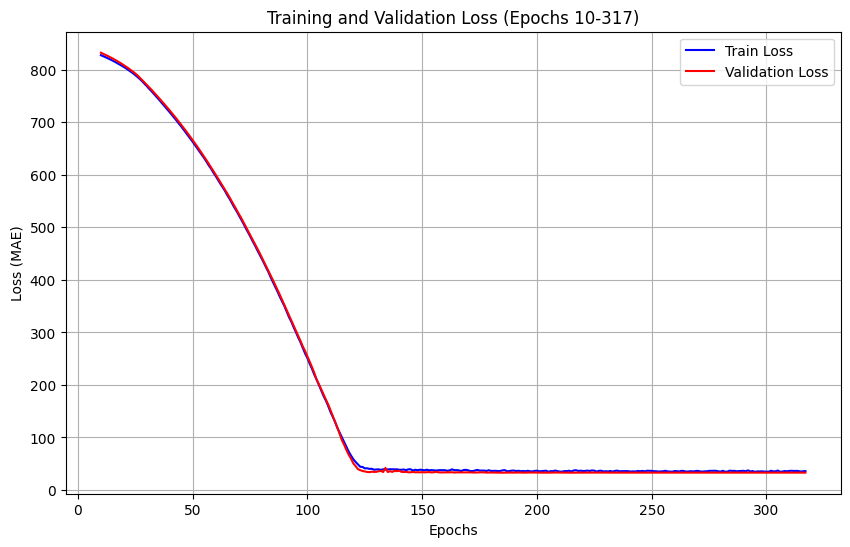

In [67]:
waist_predictor.load_state_dict(torch.load(MODEL_DIRECTORY + 'waist_predictor_temp.pth'))

# Switch to evaluation mode
waist_predictor.eval()
total_test_loss = 0.0
with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
    y_test_pred = waist_predictor(batch_X)
    test_loss = loss_function(y_test_pred, batch_y).item()
    total_test_loss += test_loss * batch_X.size(0)

avg_test_loss = total_test_loss / len(test_loader.dataset)
print(f"MAE on the test set: {avg_test_loss:.2f}")

# Plot training and validation loss from epoch 100 to 1000
start_epoch = 10
end_epoch = len(train_losses)

plt.figure(figsize=(10, 6))
plt.plot(range(start_epoch, end_epoch + 1), train_losses[start_epoch - 1:end_epoch], label="Train Loss", color='blue')
plt.plot(range(start_epoch, end_epoch + 1), val_losses[start_epoch - 1:end_epoch], label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
file_size = os.path.getsize(MODEL_DIRECTORY + 'waist_predictor_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

Model size: 75718 bytes
Model size: 0.07221031188964844 MB


In [ ]:
# torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + "/waist_predictor.pth")

## Q5

### A

Architecture:
I have implemented a slighlty adjusted version of EfficientNetB0, as it remains one of the best convolution based architectures for image classification, while also being small and efficient. The original architecture has been scaled down to fit within the 20MiB allowance.

Justification:

EfficientNet super good




### B

#### Data

In [ ]:
"""
Need to compare existing models.
Other than maybe more data augmentation
Train can get to 98+ need to close generalisation gap
"""

DATASET_PATH = DATA_DIRECTORY + 'garment_images'
LABELS_CSV = DATA_DIRECTORY + 'garment_images/train_labels.csv'
num_workers = 4
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    final_transform,
])

class GarmentImageDataset(Dataset):
    def __init__(self, root_dir, labels_csv, transform=None):
        self.root_dir = root_dir
        self.labels_df = pd.read_csv(labels_csv)
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        filename = self.labels_df.iloc[idx, 0]
        label = int(self.labels_df.iloc[idx, 1])

        img_path = os.path.join(self.root_dir, str(label), filename)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

class AugmentedDataset(Dataset):
    def __init__(self, subset, original_transform, augmented_transform, n_augmentations=0):
        self.subset = subset
        self.original_transform = original_transform
        self.augmented_transform = augmented_transform
        self.n_augmentations = n_augmentations
        self.expanded_indices = []
        for idx in range(len(subset)):
            self.expanded_indices.append((idx, 'original'))
            for _ in range(n_augmentations):
                self.expanded_indices.append((idx, 'augmented'))

    def __len__(self):
        return len(self.expanded_indices)

    def __getitem__(self, idx):
        base_idx, mode = self.expanded_indices[idx]
        image, label = self.subset[base_idx]

        if mode == 'original':
            image = self.original_transform(image)
        else:
            image = self.augmented_transform(image)

        return image, label


# Original dataset without transform
base_dataset = GarmentImageDataset(DATASET_PATH, LABELS_CSV)

# Load labels
labels_df = pd.read_csv(LABELS_CSV)
labels = labels_df.iloc[:, 1].tolist()  # assuming second column is labels
labels = np.array(labels)

# Define the stratified splitter
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.7)
for train_index, temp_index in sss1.split(np.zeros(len(labels)), labels):
    pass

temp_labels = labels[temp_index]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.66)
for val_index, test_index in sss2.split(np.zeros(len(temp_labels)), temp_labels):
    pass

# Get actual indices for subsets
val_index = np.array(temp_index)[val_index]
test_index = np.array(temp_index)[test_index]

# Create subsets
train_subset = torch.utils.data.Subset(base_dataset, train_index)
val_subset = torch.utils.data.Subset(base_dataset, val_index)
test_subset = torch.utils.data.Subset(base_dataset, test_index)

# Wrap train subset with a transform
train_dataset = AugmentedDataset(train_subset, final_transform, augmented_transform, n_augmentations=3)
val_dataset = AugmentedDataset(val_subset, final_transform, final_transform, n_augmentations=0)
test_dataset = AugmentedDataset(test_subset, final_transform, final_transform, n_augmentations=0)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Get labels for train subset only
train_labels = labels[train_index]
label_counts = Counter(train_labels)
total_samples = len(train_labels)
num_classes = len(label_counts)

class_weights = []
for label in sorted(label_counts.keys()):
    count = label_counts[label]
    weight = total_samples / (num_classes * count) if count > 0 else 0.0
    class_weights.append(weight)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(class_weights_tensor)


cuda
Train size: 3148
Validation size: 625
Test size: 1214
tensor([0.8545, 0.9645, 1.2612])


#### Models

In [ ]:
# Custom EfficientNet
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock(nn.Module):
    def __init__(self, in_ch, se_ratio=0.25):
        super().__init__()
        squeezed = max(1, int(in_ch * se_ratio))
        self.fc1 = nn.Conv2d(in_ch, squeezed, 1, bias=False)
        self.fc2 = nn.Conv2d(squeezed, in_ch, 1, bias=False)
    def forward(self, x):
        scale = F.adaptive_avg_pool2d(x, 1)
        scale = F.relu(self.fc1(scale))
        scale = torch.sigmoid(self.fc2(scale))
        return x * scale

class MBConv(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio, stride):
        super().__init__()
        mid_ch = in_ch * expand_ratio
        self.use_res = (in_ch == out_ch and stride == 1)
        self.block = nn.Sequential(
            # 1×1 expansion
            nn.Conv2d(in_ch, mid_ch, 1, bias=False),
            nn.BatchNorm2d(mid_ch),
            Swish(),
            # 3×3 depthwise
            nn.Conv2d(mid_ch, mid_ch, 3, stride, 1, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            Swish(),
            # SE
            SEBlock(mid_ch),
            # 1×1 projection
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x):
        out = self.block(x)
        return x + out if self.use_res else out

class EfficientNetE1(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            Swish()
        )

        # (in_ch, out_ch, expand_ratio, stride, repeats)
        cfgs = [
            (32,  16, 1, 1, 1),
            (16,  24, 6, 2, 1),
            (24,  40, 6, 2, 1),
            (40,  80, 6, 2, 1),
            (80, 112, 6, 1, 2),
            (112,192, 6, 2, 3),
            (192,320, 6, 1, 1)
        ]

        layers = []
        in_ch = 32
        for (c_in, c_out, exp, stride, n) in cfgs:
            for i in range(n):
                s = stride if i == 0 else 1
                layers.append(MBConv(in_ch, c_out, exp, s))
                in_ch = c_out
        self.blocks = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Conv2d(in_ch, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x)

"""
Model                          | Size (MB)
----------------------------------------
mobilenet_v3_small             | 9.81 MB
shufflenet_v2_x1_5             | 13.54 MB
mobilenet_v2                   | 13.58 MB
regnet_y_400mf                 | 16.79 MB
efficientnet_b0                | 20.44 MB
mobilenet_v3_large             | 21.10 MB
regnet_x_400mf                 | 21.23 MB
regnet_y_800mf                 | 24.76 MB
regnet_x_800mf                 | 27.93 MB
"""

# Instantiate model
fashion_classifier = models.efficientnet_b0(weights=None)
fashion_classifier.classifier = nn.Sequential(
    nn.Linear(fashion_classifier.classifier[1].in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 3)  # output 3 classes
)

fashion_classifier =models.regnet_x_400mf(weights=None)
fashion_classifier.fc = nn.Sequential(
    nn.Linear(fashion_classifier.fc.in_features, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128, 3))

fashion_classifier.to(device)
print()

#### Training

In [ ]:
# Hyperparameters
learning_rate = 1e-4
epochs = 30
weight_decay = 5e-4

criterion = nn.CrossEntropyLoss(class_weights_tensor.to(device))
optimiser = optim.AdamW(fashion_classifier.parameters(), lr=learning_rate, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=30)

# Lists to store loss and accuracy values for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
fashion_classifier.train()
correct, total = 0, 0

# Training and validation loop
for epoch in range(epochs):

    # Train the model
    fashion_classifier.train()
    train_correct, train_total = 0, 0
    running_loss = 0.0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()

        outputs = fashion_classifier(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        train_total += labels.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = running_loss / len(train_dataloader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%", end='')

    # Validation Loop
    fashion_classifier.eval()
    val_correct, val_total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = fashion_classifier(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            val_total += labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_dataloader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    # scheduler.step()

    print(f" - Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/30] - Train Loss: 1.0092, Train Accuracy: 45.71% - Validation Loss: 1.0691, Validation Accuracy: 42.72%
Epoch [2/30] - Train Loss: 0.8389, Train Accuracy: 60.26% - Validation Loss: 0.7467, Validation Accuracy: 62.40%
Epoch [3/30] - Train Loss: 0.7542, Train Accuracy: 65.15% - Validation Loss: 0.6004, Validation Accuracy: 75.04%
Epoch [4/30] - Train Loss: 0.6918, Train Accuracy: 69.35% - Validation Loss: 0.7727, Validation Accuracy: 60.00%


KeyboardInterrupt: 

#### Eval

Test Loss: 0.2278, Test Accuracy: 92.02%


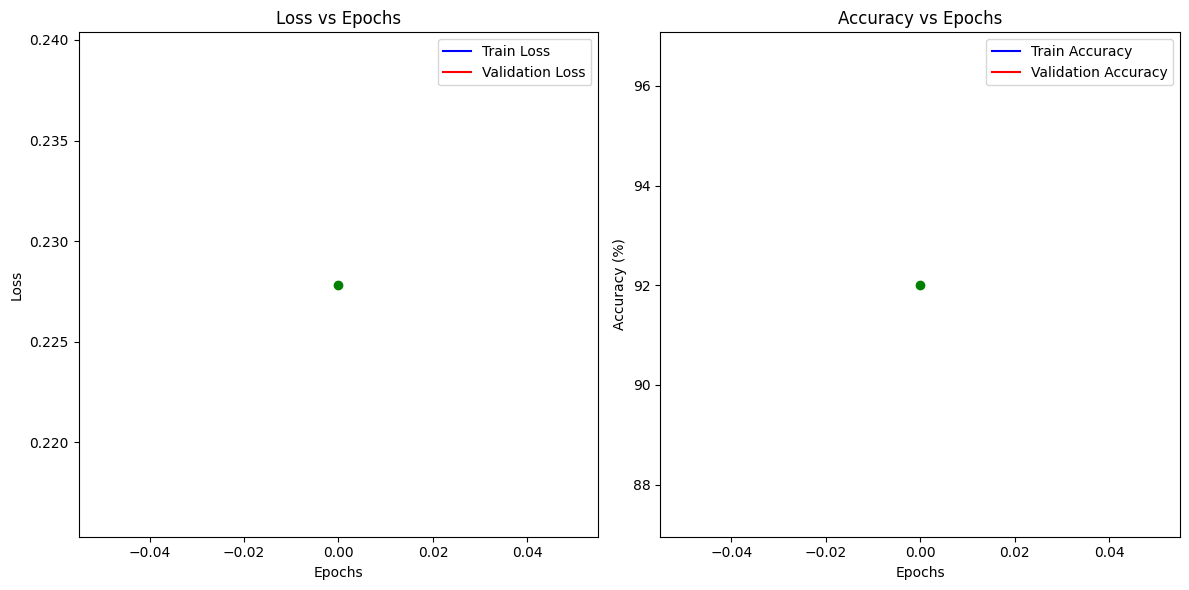

In [ ]:
fashion_classifier.eval()
test_correct, test_total = 0, 0
test_loss = 0.0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = fashion_classifier(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
average_test_loss = test_loss / len(test_dataloader)


print(f"Test Loss: {average_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


# Plot Loss vs Epochs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", color="red")
plt.plot(len(train_losses), average_test_loss, 'go')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# Plot Accuracy vs Epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_accuracies, label="Validation Accuracy", color="red")
plt.plot(len(train_accuracies), test_accuracy, 'go')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier_temp.pth")

In [ ]:
file_size = os.path.getsize(MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

Model size: 20910204 bytes
Model size: 19.941524505615234 MB


In [ ]:
# torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier.pth")

## Q6

### Code

#### Data

In [ ]:
dataset_path = DATA_DIRECTORY + "/face_images"

class FaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform or transforms.Compose([
            transforms.ToTensor()
        ])
        self.image_paths = [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('L')  # Convert to grayscale
        if self.transform:
            image = self.transform(image)
        return image

# Define split sizes
total_size = len(os.listdir(dataset_path))
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size  # Ensure total adds up

# Load the full dataset
full_dataset = FaceDataset(data_dir=dataset_path)

# Split into train, validation, and test
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

#### Autoencoder and Functions

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 192x160 → 96x80
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 96x80 → 48x40
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 48x40 → 24x20
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 24x20 → 12x10
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 12 * 10, 32)

    def forward(self, x):
        x = self.convolutions(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(32, 256 * 12 * 10)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 12x10 → 24x20
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 24x20 → 48x40
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 48x40 → 96x80
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),  # 96x80 → 192x160
            nn.Sigmoid(),  # Match input range (0, 1)
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 256, 12, 10)
        return self.deconv(x)

def mse_loss(output, target):
    return F.mse_loss(output, target)

def ssim_score(image1, image2):
    image1 = image1.squeeze().detach().cpu().numpy()
    image2 = image2.squeeze().detach().cpu().numpy()
    return ssim(image1, image2, data_range=1.0)

def plot_images(original, reconstructed):
    # Ensure the image is in the correct range [0, 1]
    reconstructed = torch.clamp(reconstructed, 0, 1)

    # Convert to NumPy and squeeze batch dimension
    original = original.squeeze().cpu().detach().numpy()
    reconstructed = reconstructed.squeeze().cpu().detach().numpy()

    # Plotting the original and reconstructed images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')

    plt.show()

# Create the Encoder and Decoder
encoder = Encoder()
decoder = Decoder()

#### Training

In [ ]:
# Define hyperparams
learning_rate = 1e-3
batch_size = 64
epochs = 20

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate)

# Some training variables
train_losses = []
val_losses = []
train_ssims = []
val_ssims = []
best_val_ssim = 0.0
temp_model_path = MODEL_DIRECTORY + "autoencoder_temp.pth"

# Training loop
for epoch in range(epochs):
    encoder.train()
    decoder.train()

    running_loss = 0.0
    running_ssim = 0.0

    # Training loop
    for i, images in enumerate(train_loader):
        optimizer.zero_grad()
        latents = encoder(images)
        reconstructed_images = decoder(latents)

        loss = mse_loss(reconstructed_images, images)
        ssim_value = ssim_score(reconstructed_images, images)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_ssim += ssim_value

    avg_loss = running_loss / len(train_loader)
    avg_ssim = running_ssim / len(train_loader)

    # Print training statistics
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, SSIM: {avg_ssim:.4f}", end='')

    # Validation
    encoder.eval()
    decoder.eval()

    running_val_loss = 0.0
    running_ssim_val = 0.0

    with torch.no_grad():
        for images in val_loader:
            latents = encoder(images)
            reconstructed_images = decoder(latents)

            val_loss = mse_loss(reconstructed_images, images)
            running_val_loss += val_loss.item()

            ssim_value = ssim_score(reconstructed_images, images)
            running_ssim_val += ssim_value

    avg_val_loss = running_val_loss / len(val_loader)
    avg_ssim_val = running_ssim_val / len(val_loader)

    # Print validation statistics
    print(f", Validation Loss: {avg_val_loss:.4f}, SSIM: {avg_ssim_val:.4f}")

    # Save best model based on SSIM
    if avg_ssim_val > best_val_ssim:
      best_val_ssim = avg_ssim_val
      torch.save({
          'encoder_state_dict': encoder.state_dict(),
          'decoder_state_dict': decoder.state_dict(),
      }, temp_model_path)
      print("Best model saved!")

    # Append losses and ssims for visualisation
    train_losses.append(avg_loss)
    val_losses.append(avg_val_loss)
    train_ssims.append(avg_ssim)
    val_ssims.append(avg_ssim_val)

KeyboardInterrupt: 

#### Testing

In [ ]:
encoder.load_state_dict(torch.load(temp_model_path)['encoder_state_dict'])
decoder.load_state_dict(torch.load(temp_model_path)['decoder_state_dict'])
encoder.eval()
decoder.eval()
running_ssim_test = 0.0
running_test_loss = 0.0
with torch.no_grad():
  for images in test_loader:
    latents = encoder(images)
    reconstructed_images = decoder(latents)

    test_loss = mse_loss(reconstructed_images, images)
    running_test_loss += test_loss.item()

    ssim_value = ssim_score(reconstructed_images, images)
    running_ssim_test += ssim_value

avg_ssim_test = running_ssim_test / len(test_loader)
avg_test_loss = running_test_loss / len(test_loader)

# Print testing statistics
print(f"Test Loss: {avg_test_loss}, SSIM: {avg_ssim_test:.4f}")

# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.plot(range(1, len(val_losses)    + 1), val_losses,      label="Validation Loss")
plt.plot(len(train_losses) + 1, avg_test_loss,              marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

# ——— Plot SSIM vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_ssims)   + 1), train_ssims,     label="Train SSIM")
plt.plot(range(1, len(val_ssims)     + 1), val_ssims,       label="Validation SSIM")
plt.plot(len(train_ssims) + 1, avg_ssim_test,               marker='o', label="Test SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("SSIM vs Epochs")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/padl_ws/models/autoencoder_temp.pth'

In [ ]:
autoencoder_size = os.path.getsize(temp_model_path) / (1024 * 1024)  # bytes → MiB
print(f"Total size: {autoencoder_size:.2f} MiB")

Total size: 12.88 MiB


In [ ]:
# torch.save({'encoder_state_dict': encoder.state_dict(), 'decoder_state_dict': decoder.state_dict(),}, MODEL_DIRECTORY + 'autoencoder.pth')

### A

#### Architecture
The autoencoder seen above was designed to take the 192x168 image and compress to a latent representation of 32D and then decompress back to the original image. The architecture is as follows:

Encoder:
* 4 convolutional layers with kernel size 4, stride 2, and padding 1

* ReLU activation after each convolution for non-linearity

* Flatten layer followed by a fully connected layer

* Linear(256×12×10, 32) → compresses to 32D latent vector

Decoder:
* Fully connected layer (Linear(32, 256×12×10)) to expand latent vector:

* 4 transposed convolutional layers that mirror the encoder

* ReLU activations in all hidden layers

* Final Sigmoid activation to normalize output to (0, 1) range

#### Justifications
Strided convolutions are used to encode as they efficiently reduce spatial resolution while learning abstract features, avoiding pooling layers. Pooling layers are avoided as they do not have learnable downsampling and is non-invertible. Transposed convolutions are used to reconstruct the image, as they can upsample the latent features back to the original resolution while preserving learned spatial patterns. It is the mirror of strided convolutions.

The linear layers in each are used to compact the final feature map from the encoder into a 32D latent vector, and then to expand this vector back into a high-dimensional feature map before decoding. This enforces a strict bottleneck, encouraging the model to learn a compressed yet meaningful representation of the input.

The size of the architecture (depth and width) was chosen to keep the model under the 20MiB limit while maintaining sufficient capacity to learn high-quality reconstructions. The model successfully achieves SSIM scores approaching or exceeding 0.9 on validation data, indicating good perceptual similarity between original and reconstructed images.

### B

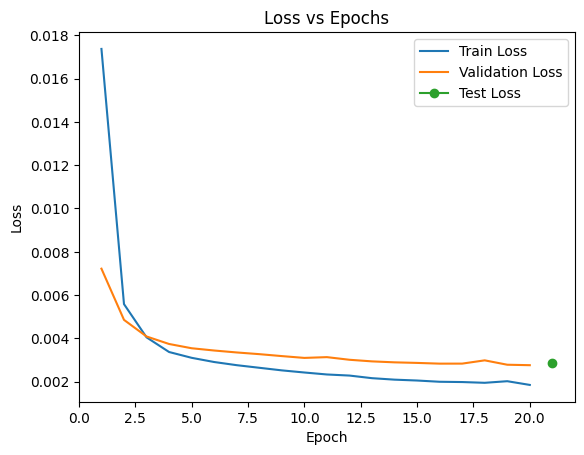

In [ ]:
# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.plot(range(1, len(val_losses)    + 1), val_losses,      label="Validation Loss")
plt.plot(len(train_losses) + 1, avg_test_loss,              marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

The graph of training losses can be seen in the evaluation section but is included here for reference
#### Hyperparameter Justification
Learning Rate - Initially decided based on prior experience with deep learning models and then changed by factors of 10 until loss decreases steadily, forming the traditional curve seen with stable convergence. The model acheives it's goal with this learning rate, so no further changes were required.

Batch Size - A batch size of 64 was chosen initially as it gives a good balance of speed and stability. Larger batch sizes are not needed as, there is already a smooth curve with relativley short training times. Smaller batches will lead to less stable convergence.

Epochs - I chose to train for 20 epochs as that was a good starting points on early iterations of the model. This hasnt been changed as it hasn't needed to, the model achieves a validation SSIM greater than 0.9 early on and a basic state saving mechanism is employed so if the model does start overtraining the damage is mitigated. The SSIM is still increasing by epoch 20 so the model could be trained for longer, but as it has achieved it's goal already, there is no need.